In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import glob

from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.io.file_ops import load_wfm, load_alpha, iter_waveforms
from RaTag.plotting import plot_waveform
from RaTag.waveform.preprocessing import moving_average, subtract_pedestal
from RaTag.el_tpc.timing_workflow import map_time_windows, map_timing_plots
from RaTag.thgem_tpc.drift_workflow import map_drift_physics
from RaTag.thgem_tpc.recoil_workflow import map_recoil_integration, map_recoil_fits, map_recoil_plots
# from RaTag.el_tpc.xray_workflow import map_xrays_events
from RaTag.io import file_ops 

# Run bootstrap and enrichment

In [ ]:
path_config21 = Path(r"C:\Users\lab\Documents\Pablo\RaTag\configs\run21_analysis.yaml")
path_config47 = Path(r"C:\Users\lab\Documents\Pablo\RaTag\configs\xrays\run47_xrays.yaml")
# run21 = bootstrap_from_config(path_config21)
# run21 = map_drift_physics(run21)

run47 = bootstrap_from_config(path_config47)
run47 = map_drift_physics(run47)

Found 2 directories in RUN47_xrays
  → Bootstrapped 2 PMT Sets and 0 Alpha Sets. (Multi-Isotope: False)
  ✓ FieldScan_Gate0060_Anode1060: Computed 'drift_field' and stored metadata
  ✓ FieldScan_Gate0060_Anode1060: Computed 'red_EL_field' and stored metadata
  ✓ FieldScan_Gate0060_Anode1060: Computed 'time_drift' and stored metadata
  ✓ FieldScan_Gate0288_Anode1288: Computed 'drift_field' and stored metadata
  ✓ FieldScan_Gate0288_Anode1288: Computed 'red_EL_field' and stored metadata
  ✓ FieldScan_Gate0288_Anode1288: Computed 'time_drift' and stored metadata


# Timing and recoil workflows

In [6]:
run21 = map_time_windows(run21, force=False)
map_timing_plots(run21)

  📂 FieldScan_Gate100_Anode2000_batch1: Loaded 't_s2_end' from cache
  📂 FieldScan_Gate100_Anode2000_batch2: Loaded 't_s2_end' from cache
  📂 FieldScan_Gate100_Anode2000_batch3: Loaded 't_s2_end' from cache
  📂 FieldScan_Gate100_Anode2000_batch4: Loaded 't_s2_end' from cache
  📂 FieldScan_Gate100_Anode2000_batch5: Loaded 't_s2_end' from cache
  📂 FieldScan_Gate100_Anode2000_batch6: Loaded 't_s2_end' from cache
  ⏭ Skipping plots for RUN_X (already exist)


Run state:
  root_directory = E:\Pablos_Mighty_measurements\raw_data\RUN21_xrays
  run_id = RUN_X
  el_field = 2350.0
  target_isotope = Th228
  pressure = 2.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.8
  drift_gap = 1.4
  sets = <6 SetPmt objects>
  gas_density = 4.877421222922505e+19
  width_s2 = 1.1
  t_s1 = 0.0
  recoil_energy = 96.8
  W_value = 22.0
  E_gamma_xray = 12300.0

  Missing:
    g_S2, alpha_calibration, isotope_ranges

In [8]:
run21i = map_recoil_integration(run21, force=False)


INTEGRATING S2 RECOILS: RUN_X
  📂 FieldScan_Gate100_Anode2000_batch1: Loaded 'n_areas_recoil' from cache
  📂 FieldScan_Gate100_Anode2000_batch2: Loaded 'n_areas_recoil' from cache
  📂 FieldScan_Gate100_Anode2000_batch3: Loaded 'n_areas_recoil' from cache
  📂 FieldScan_Gate100_Anode2000_batch4: Loaded 'n_areas_recoil' from cache
  📂 FieldScan_Gate100_Anode2000_batch5: Loaded 's2_areas' payload from disk
  ✓ FieldScan_Gate100_Anode2000_batch5: Computed 'n_areas_recoil' and cached
  📂 FieldScan_Gate100_Anode2000_batch6: Loaded 's2_areas' payload from disk
  ✓ FieldScan_Gate100_Anode2000_batch6: Computed 'n_areas_recoil' and cached


# X-ray workflow

In [10]:
run21x = map_xrays_events(run21, force=True)


IDENTIFYING X-RAY EVENTS: RUN_X
  ⚡ Force enabled: Recomputing and saving xray_areas
  Searching X-Ray window: [-2.55, 13.87] µs
    ✓ Classified 192864 frames: 200 accepted (0.1%), 192664 rejected
      - Excessive S1 reject:  96837
      - Excessive S2 reject:  98513
      - Poor Separation:      183251
      - Below Min Area:       176231
  ⚡ Force enabled: Recomputing and saving xray_areas
  Searching X-Ray window: [-3.30, 13.75] µs
    ✓ Classified 3145632 frames: 2946 accepted (0.1%), 3142686 rejected
      - Excessive S1 reject:  1578956
      - Excessive S2 reject:  1604927
      - Poor Separation:      3007367
      - Below Min Area:       2879324
  ⚡ Force enabled: Recomputing and saving xray_areas
  Searching X-Ray window: [-3.27, 13.41] µs
    ✓ Classified 3145632 frames: 3828 accepted (0.1%), 3141804 rejected
      - Excessive S1 reject:  1578803
      - Excessive S2 reject:  1604880
      - Poor Separation:      2982473
      - Below Min Area:       2903539
  ⚡ Force ena

# Check individual waveforms

In [6]:
set1 = run47.sets[1]
# aset1 = run47.alpha_sets[0]
file_idx = 0
frame_idx = 0
wf = load_wfm(set1.source_dir / set1.filenames[file_idx])
# wfa = load_alpha(aset1.source_dir / aset1.filenames[file_idx])

wf_smooth = moving_average(wf, window=1000)
wf_sub = subtract_pedestal(wf_smooth, 200)

In [44]:
t_s1 = -3.3
t_s2_min = t_s1 + set1.time_drift * 0.99
v_min = 7
t_s2_min, set1.name
t_s2_min = -0.5

Text(0.5, 1.0, 'RUN_47, Set: FieldScan_Gate0288_Anode1288')

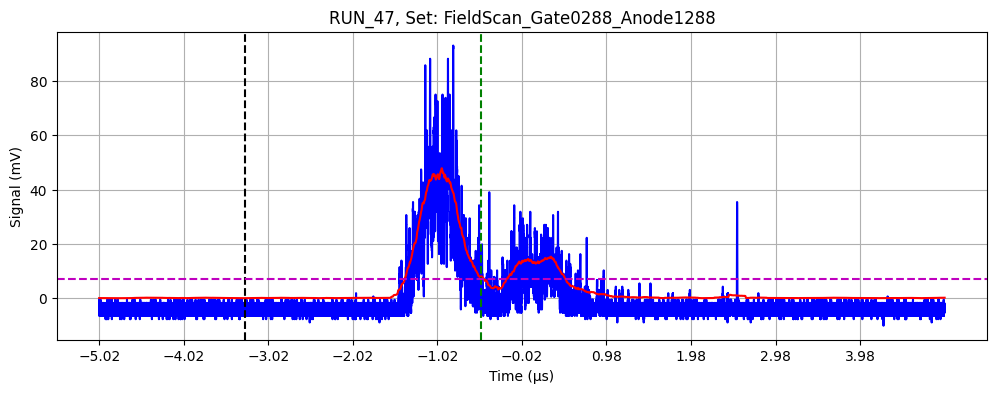

In [46]:
frame_idx -= 1
fig, ax = plt.subplots(figsize=(12, 4))

plot_waveform(wf, frame=frame_idx, ax=ax)
plot_waveform(wf_sub, frame=frame_idx, color='r', ax=ax)
ax.axvline(t_s1, color='k', linestyle='--', label='S1')

ax.axvline(t_s2_min, color='g', linestyle='--', label='S2 min')
ax.axhline(v_min, color='m', linestyle='--', label='S2 v min')
plt.title(f"{run47.run_id}, Set: {set1.name}")
# plot_waveform(wfa, frame=frame_idx, ax=ax)

Text(0.5, 1.0, 'RUN49, Set: FieldScan_Gate0768_Anode1968')

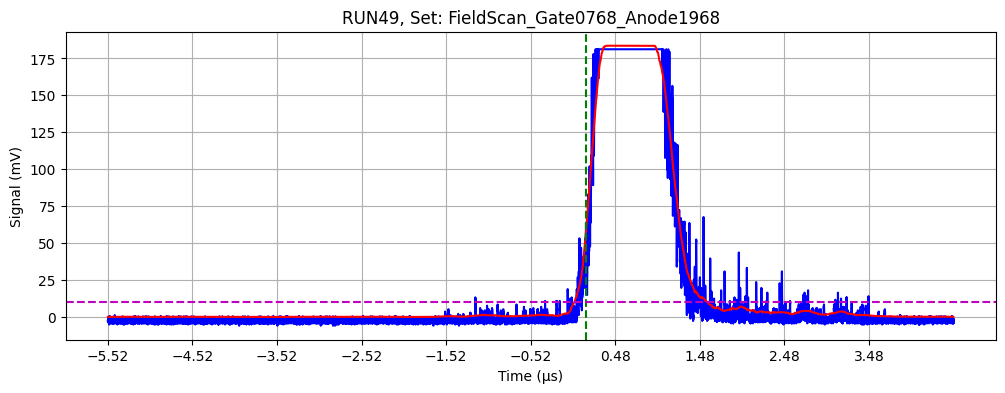

In [ ]:
frame_idx += 1
fig, ax = plt.subplots(figsize=(12, 4))

plot_waveform(wf, frame=frame_idx, ax=ax)
plot_waveform(wf_sub, frame=frame_idx, color='r', ax=ax)
ax.axvline(t_s2_min, color='g', linestyle='--', label='S2 min')
ax.axhline(v_min, color='m', linestyle='--', label='S2 v min')
plt.title(f"{run49.run_id}, Set: {set1.name}")
# plot_waveform(wfa, frame=frame_idx, ax=ax)

Text(0.5, 1.0, 'RUN45, Set: FieldScan_Gate0864_Anode2064')

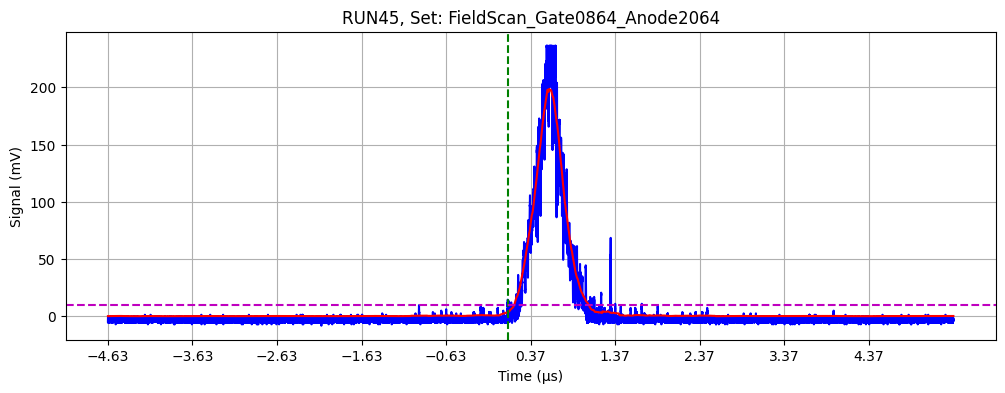

In [145]:
frame_idx += 1
fig, ax = plt.subplots(figsize=(12, 4))

plot_waveform(wf, frame=frame_idx, ax=ax)
plot_waveform(wf_sub, frame=frame_idx, color='r', ax=ax)
ax.axvline(t_s2_min, color='g', linestyle='--', label='S2 min')
ax.axhline(v_min, color='m', linestyle='--', label='S2 v min')
# plot_waveform(wfa, frame=frame_idx, ax=ax)
plt.title(f"{run45.run_id}, Set: {set1.name}")


# Clip rates

In [6]:

def get_clip_rates(areas_path):
    files = sorted(glob.glob(areas_path))
    clip_rates = []
    for f in files:
        s2_areas = np.load(f, allow_pickle=True)
        stats = s2_areas['stats'].item()
        clip_rate = stats['pass_clip'] / stats['total']
        clip_rates.append(clip_rate)
    return clip_rates
    

In [7]:
run_paths = ["RUN43_EL25kVcm", "RUN44_EL20kVcm", "RUN45_EL30kVcm",
              "RUN46_EL25kVcm", "RUN48_EL20kVcm", "RUN49_EL30kVcm", "RUN50_EL27p5kVcm"]
areas_paths = [f"\\\\Lab104con\\K\\AXO-RITA\\processed\\{run}\\s2_areas\\*.npz" for run in run_paths]
clip_rates_list = [get_clip_rates(path) for path in areas_paths]

RUN43_EL25kVcm: [0.961838905775076, 0.9619706180344478, 0.9615349544072949, 0.9591489361702128, 0.9581256332320162, 0.9548632218844985, 0.9511195542046605, 0.9418743667679838, 0.9364792299898683]
RUN44_EL20kVcm: [0.9712208713272543, 0.9700911854103343, 0.9694376899696049, 0.9697973657548126, 0.9695592705167173, 0.9702532928064843, 0.969209726443769, 0.9696301925025329, 0.9685612968591693]
RUN45_EL30kVcm: [0.9080395136778115, 0.8950303951367781, 0.8679229989868288, 0.8100455927051672, 0.7065400202634246, 0.6651013171225937, 0.6049594731509625, 0.5417122593718339, 0.4912563323201621, 0.4603850050658561]
RUN46_EL25kVcm: [0.9676950354609929, 0.9645440729483282, 0.9638601823708207, 0.9628014184397163, 0.9606889564336373, 0.9593110435663628, 0.9564387031408308, 0.9546707193515704, 0.9513677811550152, 0.945871327254306, 0.9385764944275583, 0.9210688956433637, 0.9004052684903748]
RUN48_EL20kVcm: [0.969564336372847, 0.9679452887537994, 0.9668632218844985, 0.9674769431920884, 0.967580547112462, 

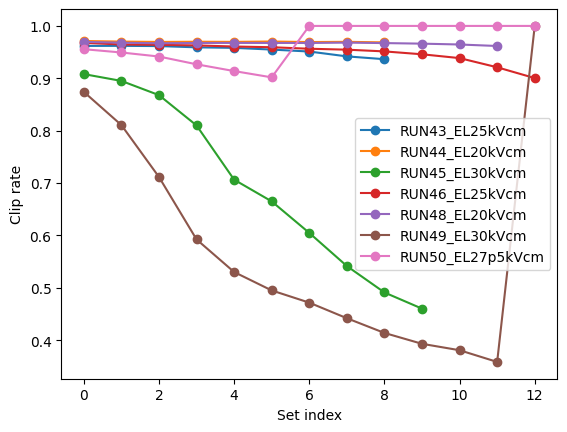

In [ ]:
for i, run in enumerate(run_paths):
    print(f"{run}: {clip_rates_list[i]}")
    plt.plot(clip_rates_list[i], 'o-', label=f'{run}')

plt.gca().set(xlabel='Set index', ylabel='Clip rate', )
plt.legend()

# Peek alpha calibration

In [64]:
areas_paths = r'\\Lab104con\K\AXO-RITA\processed\RUN53_alphas\s2_areas\*.npz'
files = sorted(glob.glob(areas_paths))
file = np.load(files[0], allow_pickle=True)

names = ['20 kV/cm', '22.5 kV/cm', '25 kV/cm', '27.5 kV/cm', '30 kV/cm']
files

['\\\\Lab104con\\K\\AXO-RITA\\processed\\RUN53_alphas\\s2_areas\\AlphaScan_Gate1344_Anode2144_s2_areas.npz',
 '\\\\Lab104con\\K\\AXO-RITA\\processed\\RUN53_alphas\\s2_areas\\AlphaScan_Gate1344_Anode2244_s2_areas.npz',
 '\\\\Lab104con\\K\\AXO-RITA\\processed\\RUN53_alphas\\s2_areas\\AlphaScan_Gate1344_Anode2344_s2_areas.npz',
 '\\\\Lab104con\\K\\AXO-RITA\\processed\\RUN53_alphas\\s2_areas\\AlphaScan_Gate1344_Anode2444_s2_areas.npz',
 '\\\\Lab104con\\K\\AXO-RITA\\processed\\RUN53_alphas\\s2_areas\\AlphaScan_Gate1344_Anode2544_s2_areas.npz']

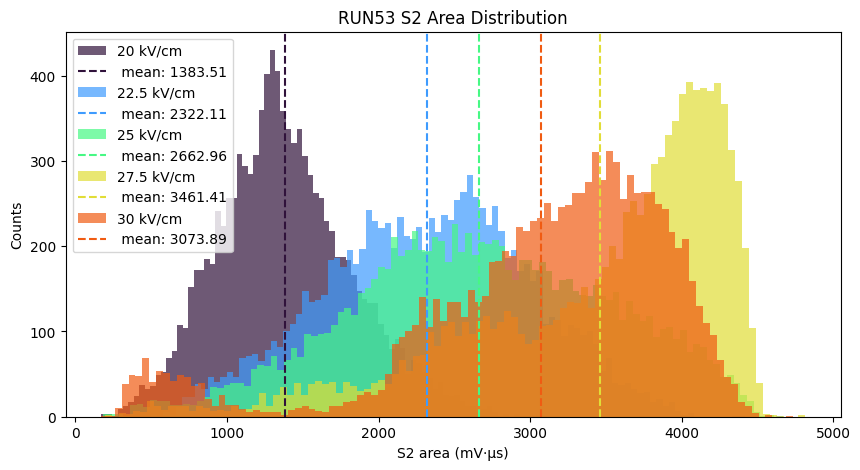

In [69]:
plt.figure(figsize=(10, 5))
s2_centroids = []
for i, f in enumerate(files):
    file = np.load(f, allow_pickle=True)
    s2_areas = file['s2_areas']
    s2_centroids.append(np.mean(s2_areas))
    plt.hist(s2_areas, bins=100, alpha=0.7, color=plt.cm.turbo(i/len(files)), label=names[i])
    plt.gca().set(xlabel='S2 area (mV·µs)', ylabel='Counts', title='RUN53 S2 Area Distribution')
    plt.axvline(np.mean(s2_areas), linestyle='--', color=plt.cm.turbo(i/len(files)), label=f' mean: {np.mean(s2_areas):.2f}')

plt.legend()
plt.show()

[Text(0.5, 0, 'Drift Voltage (kV/cm)'),
 Text(0, 0.5, 'S2 Area Centroid (mV·µs)'),
 Text(0.5, 1.0, 'RUN53 S2 Area Centroid vs Drift Voltage')]

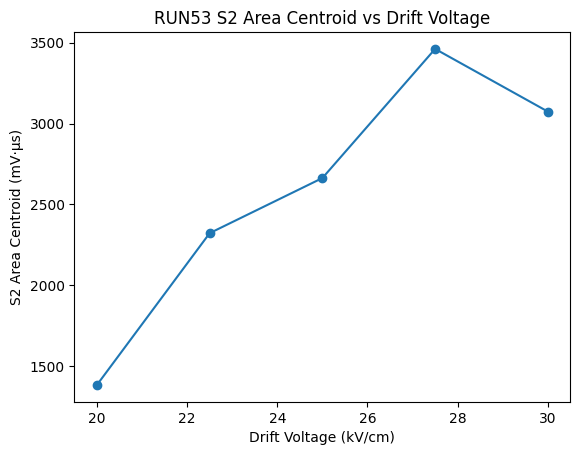

In [71]:
dv = [20, 22.5, 25, 27.5, 30]
plt.plot(dv, s2_centroids, 'o-', label='S2 Centroid vs Drift Voltage')
plt.gca().set(xlabel='Drift Voltage (kV/cm)', ylabel='S2 Area Centroid (mV·µs)', title='RUN53 S2 Area Centroid vs Drift Voltage')

# Si detector on recoils:

In [1]:
from RaTag.io.file_ops import load_wfm, load_alpha
from RaTag.plotting import plot_waveform

In [4]:
path_wfm = r'\\Lab104con\K\AXO-RITA\raw_data\RUN53_alphas\AlphaScan_Gate1344_Anode2144\RUN53_20260814_Gate1344_Anode2144_Batch_1Wfm_Ch4.wfm'
wf = load_alpha(path_wfm)
wf_smooth = moving_average(wf, window=1000)

In [15]:
path_pmt = r'\\Lab104con\K\AXO-RITA\raw_data\RUN53_alphas\AlphaScan_Gate1344_Anode2144\RUN53_20260814_Gate1344_Anode2144_Batch_1Wfm_Ch3.wfm'
wfp = load_alpha(path_pmt)
wfp_smooth = moving_average(wfp, window=1000)

In [5]:
path_wfm2 = r'\\Lab104con\K\AXO-RITA\raw_data\RUN44_EL20kVcm\FieldScan_Gate1344_Anode2144\RUN44_Gate1344_Anode2144_20260811-224954_Batch001_CH4.wfm'
wf2 = load_alpha(path_wfm2)
wf2_smooth = moving_average(wf2, window=1000)

In [18]:
path_pmt2 = r'\\Lab104con\K\AXO-RITA\raw_data\RUN44_EL20kVcm\FieldScan_Gate1344_Anode2144\RUN44_Gate1344_Anode2144_20260811-224954_Batch001_CH3.wfm'
wfp2 = load_alpha(path_pmt2)
wfp2_smooth = moving_average(wfp2, window=1000)

In [59]:
np.max(wf_smooth.v, axis=1).shape

(496,)

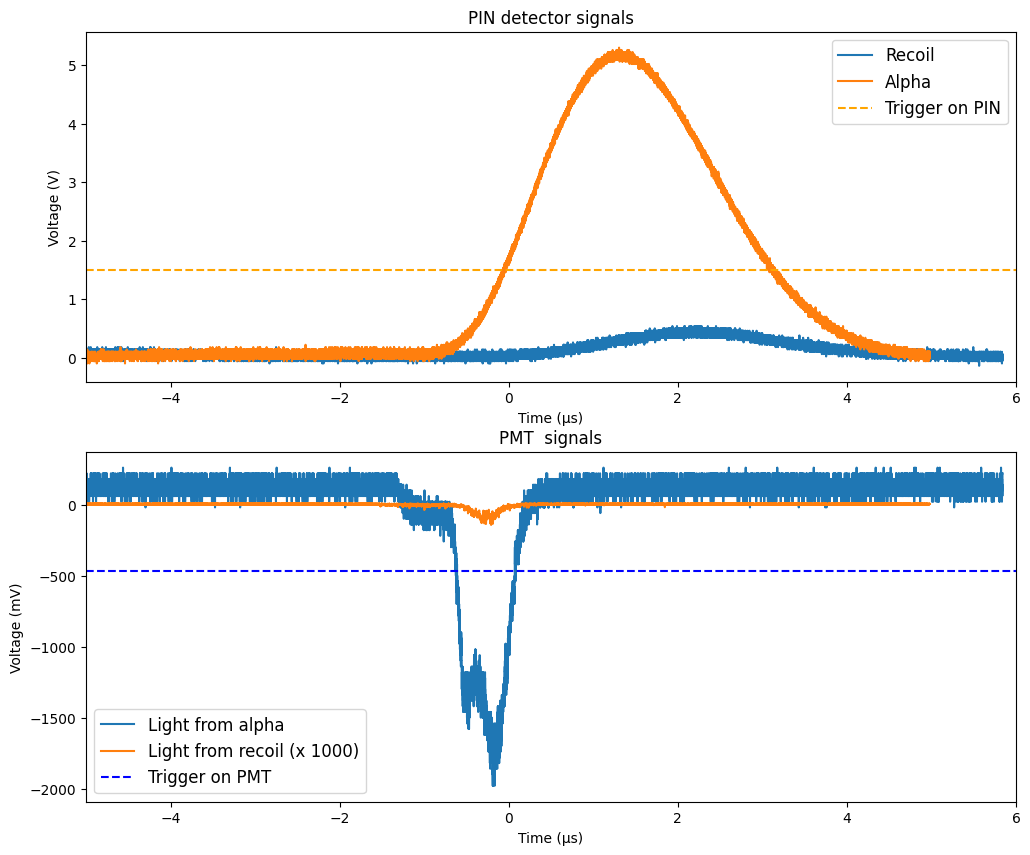

: 

In [ ]:
idx -= 1
fig, ax = plt.subplots(2, figsize=(12, 10))
ax[0].plot(wf.t, wf.v[idx,:], label='Recoil')
# ax[0].plot(wf.t, wf_smooth.v[idx,:], color='r', label='smoothed')

ax[0].plot(wf2.t, wf2.v[idx,:], label='Alpha')
# ax[0].plot(wf2.t, wf2_smooth.v[idx,:], color='g', label='smoothed')
ax[0].axhline(1.5, color='orange', linestyle='--', label='Trigger on PIN')
ax[0].set(xlabel='Time (µs)', ylabel='Voltage (V)', title=f'PIN detector signals', xlim=(-5, 6))
ax[0].legend(fontsize=12)

ax[1].plot(wfp.t, wfp.v[idx,:] * 1000, label='Light from alpha')
# ax[1].plot(wfp.t, wfp_smooth.v[idx,:], color='r', label='smoothed')
ax[1].plot(wfp2.t, wfp2.v[idx,:] * 1000, label='Light from recoil (x 1000)')
# ax[1].plot(wfp2.t, wfp2_smooth.v[idx,:], color='g', label='smoothed')
ax[1].axhline(-470, color='b', linestyle='--', label='Trigger on PMT')
ax[1].set(xlabel='Time (µs)', ylabel='Voltage (mV)', title=f'PMT  signals', xlim=(-5, 6))
ax[1].legend(fontsize=12)


In [55]:
files_ch4 = sorted(glob.glob(r'\\Lab104con\K\AXO-RITA\raw_data\RUN53_alphas\AlphaScan_Gate1344_Anode2144\RUN53_20260814_Gate1344_Anode2144_Batch_*Wfm_Ch4.wfm'))

In [60]:
peaks = []
for i, f in enumerate(files_ch4):
    wf = load_alpha(f)
    wf_smooth = moving_average(wf, window=1000)
    peaks.extend(np.max(wf_smooth.v, axis=1))

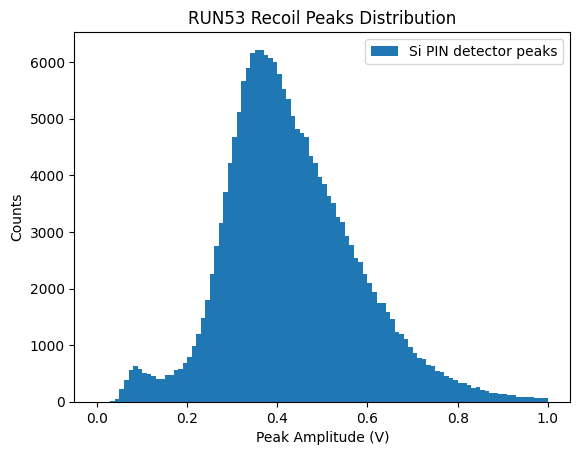

In [63]:
plt.hist(peaks, bins=100, range=(0, 1), label='Si PIN detector peaks')
plt.gca().set(xlabel='Peak Amplitude (V)', ylabel='Counts', title='RUN53 Recoil Peaks Distribution')
plt.legend()